# Fine-Tuning Strategies for Transfer Learning: Frozen vs. Full Fine-Tuning

**Research question**: How does the depth of fine-tuning on a pretrained transformer language model affect text classification accuracy and training cost, when adapting a general-purpose masked-language model to a topic classification task?

**Dataset**: AG News (4 topic classes — World, Sports, Business, Sci/Tech; ~18K train / 2K val / 4K test used here, subsampled from the full 120K/7.6K corpus to fit a short training budget).

**Model**: DistilBERT (`distilbert-base-uncased`, pretrained via masked language modeling).

**Conditions compared**:
- frozen backbone (only the classification head unfrozen, everything else frozen)
- full fine-tuning (entire network trainable)

**Measuring**: validation/test accuracy, per-class F1, convergence speed, training time, and number of trainable parameters, to characterize the accuracy–efficiency tradeoff between the two regimes.

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Dataset & Preprocessing

We load AG News directly from the Hugging Face `datasets` hub — 4 balanced topic classes. To keep training within a short budget, we subsample 20,000 training examples (split 90/10 into train/validation) and 4,000 test examples, rather than the full 120K/7.6K corpus — large enough to show a clear frozen-vs-finetune gap without requiring hours of GPU time.

Text is tokenized with DistilBERT's tokenizer, truncated/padded to 128 tokens (AG News snippets are short, so this comfortably covers full examples), producing `input_ids` and `attention_mask` tensors the model consumes directly.

In [24]:
raw = load_dataset("ag_news")
class_names = raw["train"].features["label"].names
print(class_names)   # ['World', 'Sports', 'Business', 'Sci/Tech']
print(raw)

['World', 'Sports', 'Business', 'Sci/Tech']
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [25]:
train_full = raw["train"].shuffle(seed=42).select(range(20000))
test_data = raw["test"].shuffle(seed=42).select(range(4000))

split = train_full.train_test_split(test_size=0.1, seed=42)
train_data = split["train"]
val_data = split["test"]

print(len(train_data), len(val_data), len(test_data))

18000 2000 4000


In [26]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_data = train_data.map(tokenize_fn, batched=True)
val_data = val_data.map(tokenize_fn, batched=True)
test_data = test_data.map(tokenize_fn, batched=True)

cols = ["input_ids", "attention_mask", "label"]
train_data.set_format(type="torch", columns=cols)
val_data.set_format(type="torch", columns=cols)
test_data.set_format(type="torch", columns=cols)

batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

# Model Setup: Two Fine-Tuning Strategies

`build_model()` controls how much of DistilBERT is trainable. In "frozen" mode, every parameter except the `pre_classifier`/`classifier` head is locked (`requires_grad = False`), so only ~600K of the ~67M parameters actually update. In "full" mode, all transformer layers plus the head are trainable. Unlike the CNN case, DistilBERT's 6 transformer blocks don't map onto a natural "partial" middle ground for this task, so we compare the two clearest ends of the spectrum: frozen and full.

In [27]:
def build_model(mode: str):
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

    if mode == "frozen":
        for name, param in model.named_parameters():
            # keep only the classification head trainable
            if not name.startswith("classifier") and not name.startswith("pre_classifier"):
                param.requires_grad = False
    elif mode == "full":
        pass  # everything stays trainable

    return model.to(device)

In [28]:
def train_model(model, train_loader, val_loader, epochs, lr):
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

    start = time.time()
    for epoch in range(epochs):
        model.train()
        total_loss, correct, count = 0, 0, 0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item() * labels.size(0)
            correct += (outputs.logits.argmax(1) == labels).sum().item()
            count += labels.size(0)

        train_loss, train_acc = total_loss / count, correct / count

        model.eval()
        v_loss, v_correct, v_count = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["label"].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                v_loss += loss.item() * labels.size(0)
                v_correct += (outputs.logits.argmax(1) == labels).sum().item()
                v_count += labels.size(0)
        val_loss, val_acc = v_loss / v_count, v_correct / v_count

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} | train_loss {train_loss:.4f} acc {train_acc:.4f} | val_loss {val_loss:.4f} acc {val_acc:.4f}")

    history["time"] = time.time() - start
    print(f"Training time: {history['time']:.1f}s")
    return history

# Training Runs

Each condition is trained with `train_model()`, which reports the trainable-parameter count, per-epoch train/val loss and accuracy, and total training time. The two conditions intentionally use different learning rates: frozen (head-only) training needs a large LR (1e-3) since it has few parameters starting from random weights, while full fine-tuning needs a small LR (2e-5) — a large LR here would destroy DistilBERT's pretrained weights in the first few steps.

## Frozen (Head Only)
Only the classification head is trained; all DistilBERT transformer layers stay frozen at their pretrained values.

In [29]:
print("FROZEN (head only)")
frozen_model = build_model("frozen")
frozen_history = train_model(frozen_model, train_loader, val_loader, epochs=10, lr=1e-3)

FROZEN (head only)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 593,668 / 66,956,548 (0.89%)
Epoch 1/10 | train_loss 0.3654 acc 0.8704 | val_loss 0.3404 acc 0.8850
Epoch 2/10 | train_loss 0.3053 acc 0.8894 | val_loss 0.3419 acc 0.8770
Epoch 3/10 | train_loss 0.2878 acc 0.8951 | val_loss 0.3122 acc 0.8855
Epoch 4/10 | train_loss 0.2692 acc 0.9020 | val_loss 0.3117 acc 0.8885
Epoch 5/10 | train_loss 0.2576 acc 0.9051 | val_loss 0.2874 acc 0.8960
Epoch 6/10 | train_loss 0.2483 acc 0.9073 | val_loss 0.2993 acc 0.8965
Epoch 7/10 | train_loss 0.2378 acc 0.9124 | val_loss 0.2955 acc 0.8950
Epoch 8/10 | train_loss 0.2285 acc 0.9151 | val_loss 0.2804 acc 0.9015
Epoch 9/10 | train_loss 0.2212 acc 0.9171 | val_loss 0.2806 acc 0.8990
Epoch 10/10 | train_loss 0.2150 acc 0.9207 | val_loss 0.2784 acc 0.9015
Training time: 757.9s


## Full Fine-Tuning
Every parameter — all 6 transformer blocks plus the head — is trainable.

In [30]:
print("FULL FINETUNE")
finetune_model = build_model("full")
finetune_history = train_model(finetune_model, train_loader, val_loader, epochs=10, lr=2e-5)

FULL FINETUNE


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 66,956,548 / 66,956,548 (100.00%)
Epoch 1/10 | train_loss 0.3410 acc 0.8943 | val_loss 0.2694 acc 0.9110
Epoch 2/10 | train_loss 0.1775 acc 0.9407 | val_loss 0.2457 acc 0.9200
Epoch 3/10 | train_loss 0.1218 acc 0.9616 | val_loss 0.2411 acc 0.9240
Epoch 4/10 | train_loss 0.0803 acc 0.9765 | val_loss 0.2623 acc 0.9205
Epoch 5/10 | train_loss 0.0500 acc 0.9861 | val_loss 0.3073 acc 0.9210
Epoch 6/10 | train_loss 0.0303 acc 0.9924 | val_loss 0.3206 acc 0.9170
Epoch 7/10 | train_loss 0.0187 acc 0.9955 | val_loss 0.3441 acc 0.9185
Epoch 8/10 | train_loss 0.0145 acc 0.9962 | val_loss 0.3578 acc 0.9160
Epoch 9/10 | train_loss 0.0091 acc 0.9979 | val_loss 0.3673 acc 0.9205
Epoch 10/10 | train_loss 0.0074 acc 0.9984 | val_loss 0.3693 acc 0.9210
Training time: 2047.7s


# Qualitative Check — Sample Predictions

Before quantifying performance, we spot-check a handful of test predictions from each model to sanity-check that training worked as expected.

In [31]:
def show_predictions(model, dataset, class_names, n=6):
    model.eval()
    idxs = np.random.choice(len(dataset), n, replace=False)
    for idx in idxs:
        item = dataset[idx]
        input_ids = item["input_ids"].unsqueeze(0).to(device)
        attention_mask = item["attention_mask"].unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(input_ids=input_ids, attention_mask=attention_mask).logits.argmax(1).item()
        text = tokenizer.decode(item["input_ids"], skip_special_tokens=True)
        print(f"True: {class_names[item['label']]:10s} | Pred: {class_names[pred]:10s} | {text[:90]}...")
        print("-" * 80)

print("Frozen model:")
show_predictions(frozen_model, test_data, class_names)
print("\nFinetuned model:")
show_predictions(finetune_model, test_data, class_names)

Frozen model:
True: Sports     | Pred: World      | yankees, brown go down swinging kevin brown ' s frustrating season finally reached a boili...
--------------------------------------------------------------------------------
True: World      | Pred: World      | iraqi guardsmen ring najaf shrine us and iraqi forces battled militants in najaf on tuesda...
--------------------------------------------------------------------------------
True: Sci/Tech   | Pred: Sci/Tech   | astronaut # 39 ; s kudos to rutan i applaud burt rutan and the spaceshipone team for their...
--------------------------------------------------------------------------------
True: Sports     | Pred: Sports     | harris # 39 ; three - run double in ninth sinks gagne los angeles - paul lo duca never got...
--------------------------------------------------------------------------------
True: World      | Pred: Sports     | usc, miami top bcs standings, not okla. southern california took the top spot monday in th...
--

# Results Analysis

We plot validation accuracy and loss curves across epochs to compare convergence behavior between the two training regimes, followed by a direct training-time comparison.

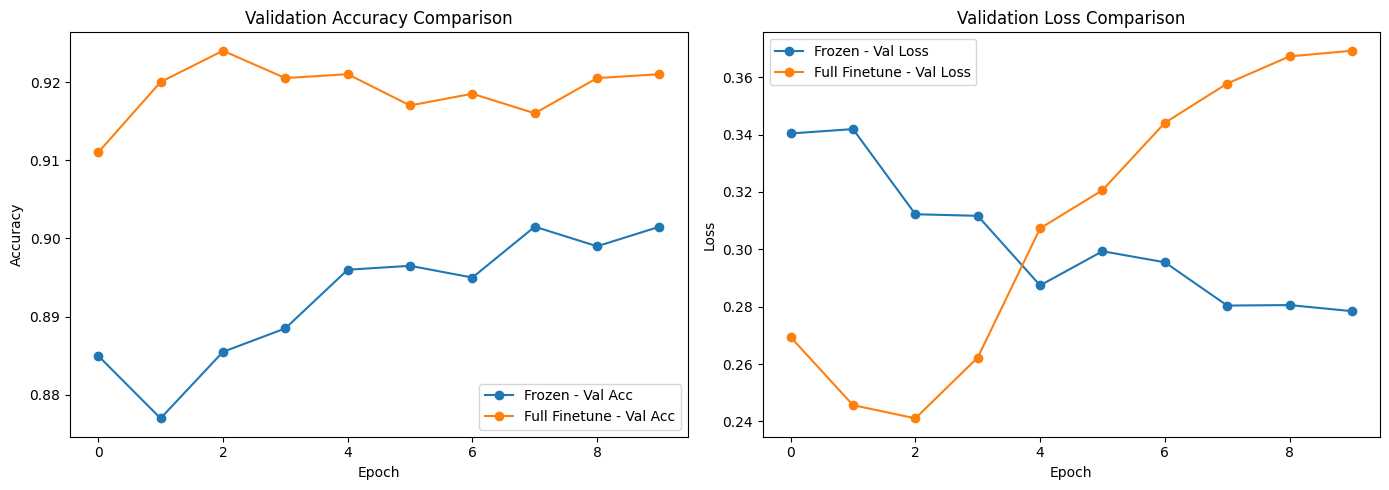

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(frozen_history["val_acc"], label="Frozen - Val Acc", marker='o')
axes[0].plot(finetune_history["val_acc"], label="Full Finetune - Val Acc", marker='o')
axes[0].set_title("Validation Accuracy Comparison")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(frozen_history["val_loss"], label="Frozen - Val Loss", marker='o')
axes[1].plot(finetune_history["val_loss"], label="Full Finetune - Val Loss", marker='o')
axes[1].set_title("Validation Loss Comparison")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()

# Training Time Comparison

We plot a bar chart in order to compare the Training time of the frozen and full finetune models

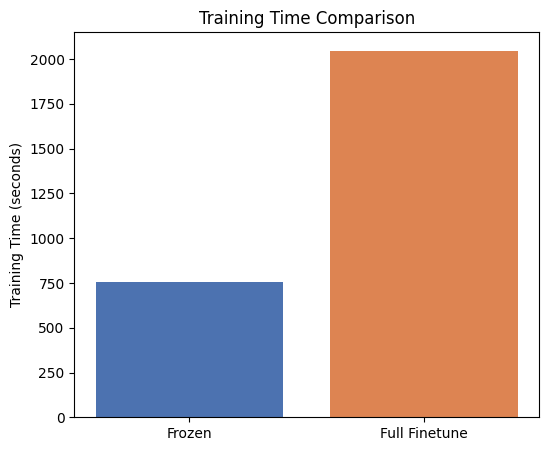

In [33]:
plt.figure(figsize=(6, 5))
plt.bar(["Frozen", "Full Finetune"],
        [frozen_history["time"], finetune_history["time"]],
        color=["#4C72B0", "#DD8452"])
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.show()

# Confusion Matrices

Using confusion matrices to check whether classification errors are concentrated between specific topic pairs (e.g. Business and Sci/Tech news often share vocabulary — companies, products, technology deals) rather than spread evenly across all classes.

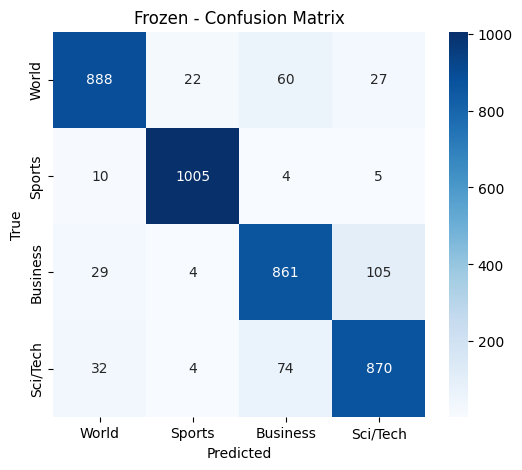

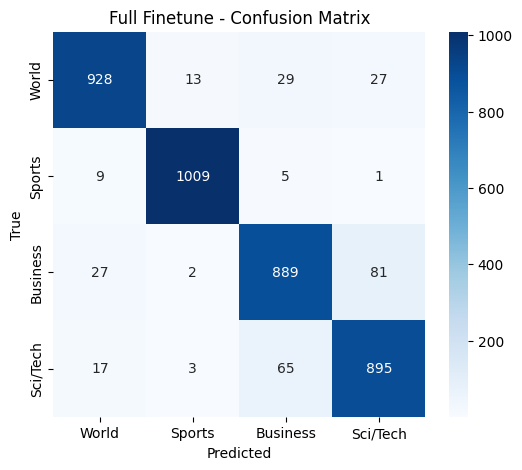

Frozen report:
               precision    recall  f1-score   support

       World       0.93      0.89      0.91       997
      Sports       0.97      0.98      0.98      1024
    Business       0.86      0.86      0.86       999
    Sci/Tech       0.86      0.89      0.88       980

    accuracy                           0.91      4000
   macro avg       0.91      0.91      0.91      4000
weighted avg       0.91      0.91      0.91      4000

Finetune report:
               precision    recall  f1-score   support

       World       0.95      0.93      0.94       997
      Sports       0.98      0.99      0.98      1024
    Business       0.90      0.89      0.89       999
    Sci/Tech       0.89      0.91      0.90       980

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_preds.extend(outputs.logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

frozen_preds, frozen_labels = get_predictions(frozen_model, test_loader)
finetune_preds, finetune_labels = get_predictions(finetune_model, test_loader)

def plot_confusion(preds, labels, class_names, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()

plot_confusion(frozen_preds, frozen_labels, class_names, "Frozen - Confusion Matrix")
plot_confusion(finetune_preds, finetune_labels, class_names, "Full Finetune - Confusion Matrix")

print("Frozen report:\n", classification_report(frozen_labels, frozen_preds, target_names=class_names))
print("Finetune report:\n", classification_report(finetune_labels, finetune_preds, target_names=class_names))

# Per-Class F1 Score Comparison

Using bar charts to compare F1 Scores for the two models on each of the 4 categories in the dataset (World, Sports, Buisness, Sci/Tech)

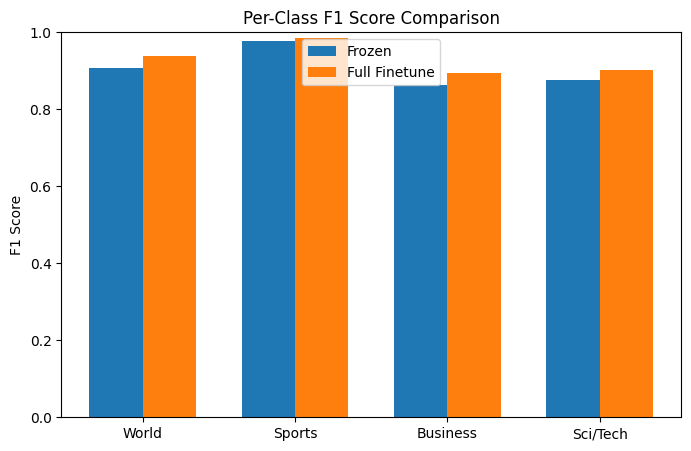

In [35]:
from sklearn.metrics import f1_score

frozen_f1 = f1_score(frozen_labels, frozen_preds, average=None)
finetune_f1 = f1_score(finetune_labels, finetune_preds, average=None)

x = np.arange(len(class_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, frozen_f1, width, label="Frozen")
plt.bar(x + width/2, finetune_f1, width, label="Full Finetune")
plt.xticks(x, class_names)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score Comparison")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [36]:
frozen_test_acc = (frozen_preds == frozen_labels).mean()
finetune_test_acc = (finetune_preds == finetune_labels).mean()

def trainable_pct(model):
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return 100 * t / total

results = pd.DataFrame({
    "Model": ["Frozen (head only)", "Full Finetune"],
    "Trainable Params %": [trainable_pct(frozen_model), trainable_pct(finetune_model)],
    "Final Train Acc": [frozen_history["train_acc"][-1], finetune_history["train_acc"][-1]],
    "Final Val Acc": [frozen_history["val_acc"][-1], finetune_history["val_acc"][-1]],
    "Test Acc": [frozen_test_acc, finetune_test_acc],
    "Train Time (s)": [frozen_history["time"], finetune_history["time"]],
})
results

,Model,Trainable Params %,Final Train Acc,Final Val Acc,Test Acc,Train Time (s)
0,Frozen (head only),0.886647,0.920667,0.9015,0.90600,757.884705
1,Full Finetune,100.000000,0.998444,0.9210,0.93025,2047.715744


In [37]:
torch.save(frozen_model.state_dict(), "frozen_distilbert.pth")
torch.save(finetune_model.state_dict(), "finetuned_distilbert.pth")
print("Models saved.")

Models saved.


# Conclusion

This experiment tested whether full fine-tuning of DistilBERT improves topic classification accuracy on AG News relative to freezing the pretrained backbone and training only the classification head, and at what cost in training time. Trained for 10 epochs each, full fine-tuning reached the higher test accuracy (93.0%) compared to the frozen backbone (90.6%), and also had higher F1 on every class — most notably World (0.94 vs 0.91) and Business/Sci-Tech, the two categories both models found hardest to separate, likely due to shared vocabulary (companies, products, and technology deals appear in both). This came at a steep cost in training time: full fine-tuning took roughly 2.7x as long (2048s vs. 758s) while updating 100% of the model's ~67M parameters versus just 0.89% for the frozen head.

The two models also diverged sharply in how they behaved over training. The frozen head's train and validation accuracy stayed close together throughout all 10 epochs (92.1% vs 90.2% by the end), still improving slowly, a sign it was under capacity, not overfitting, and could likely have kept training productively for more epochs. Full fine-tuning told the opposite story: training accuracy climbed almost to 100% (99.8%) by epoch 10, but validation loss bottomed out around epoch 3 (0.241) and then rose steadily to 0.369 by epoch 10, even as validation accuracy plateaued and drifted slightly downward from its epoch-3 peak of 92.4%. In other words, the fully fine-tuned model overfit the training set well before the 10-epoch run was over, and several of those later epochs were actively counterproductive — an early-stopping checkpoint around epoch 3 would likely have matched or beaten the final model's accuracy at a fraction of the training cost.

This overfitting risk is the natural consequence of giving a 67M-parameter model full freedom to fit an 18K-example training set: it has more than enough capacity to start memorizing rather than generalizing once it moves past the point where pretrained features already transfer well. This is also the flip side of the CNN transfer-learning case on Oxford-IIIT Pets, where a frozen backbone won outright on a small dataset — the risk of overfitting when unfreezing everything scales with how much spare model capacity there is relative to the data, and that risk shows up here too once training runs long enough.

The practical takeaway: full fine-tuning still wins on raw accuracy, but this run makes clear it needs a validation-based stopping criterion (early stopping or checkpoint selection) to actually capture that advantage without wasting most of the training budget overfitting. The frozen head, while less accurate, is more forgiving of over-training and remains the safer default when compute or tuning time is limited.